In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

Epoch 0, Loss: 342.3514
Epoch 200, Loss: 0.9289
Epoch 400, Loss: 0.8982
Epoch 600, Loss: 0.8934
Epoch 800, Loss: 0.8927
学到的 w: 3.10 (应该是 3)
学到的 b: 1.53 (应该是 2)
tensor(0.8926, grad_fn=<MseLossBackward0>)


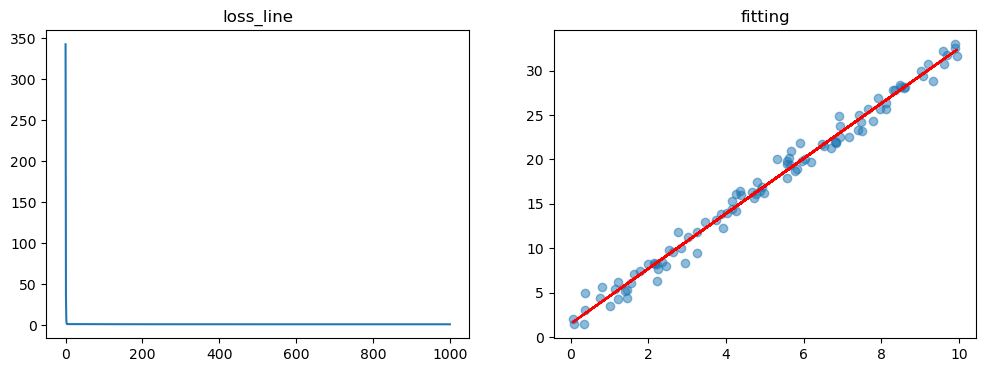

In [13]:
# 生成一些线性数据（y = 3x + 2 + 噪声）
x = torch.rand(100,1)*10
y = 3*x + 2 + torch.randn(100,1)
# TODO: 用 nn.Module 定义一个单层网络（就是线性回归！）
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(1,1)
    def forward(self,x):
        return self.lin(x)

model = LinearRegression()
loss_func = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr = 0.01)
losses = []
for epoch in range(1000):
    y_pred = model(x)
    loss = loss_func(y_pred,y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# 结果
print(f"学到的 w: {model.lin.weight.item():.2f} (应该是 3)")
print(f"学到的 b: {model.lin.bias.item():.2f} (应该是 2)")
print (loss_func(model(x), y))
# TODO: 训练这个模型
# 1. 创建模型实例
# 2. 定义优化器 (SGD, lr=0.01)
# 3. 训练1000轮，记录损失
# 4. 画出数据和拟合线

# 期望：学到的参数接近 w=3, b=2
# 画图
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(losses)
plt.title('loss_line')

plt.subplot(1,2,2)
plt.scatter(x.numpy(), y.numpy(), alpha=0.5)
plt.plot(x.numpy(), model(x).detach().numpy(), 'r-')
plt.title('fitting')

plt.show()

Epoch 0, Loss: 2.1533
Epoch 200, Loss: 0.1003
Epoch 400, Loss: 0.0640
Epoch 600, Loss: 0.0270
Epoch 800, Loss: 0.0114
Epoch 1000, Loss: 0.0080
Epoch 1200, Loss: 0.0066
Epoch 1400, Loss: 0.0063
Epoch 1600, Loss: 0.0062
Epoch 1800, Loss: 0.0061


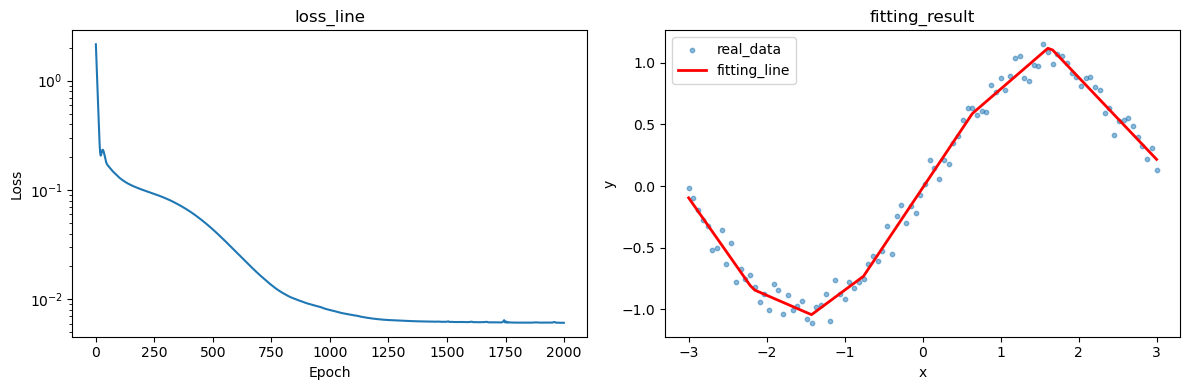

最终损失: 0.006106


In [15]:
# 生成正弦数据
x = torch.linspace(-3, 3, 100).reshape(-1, 1)
true_y = torch.sin(x) + 0.1 * torch.randn_like(x)

class TwoLayers(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1,10)
        self.fc2 = nn.Linear(10,1)

    def forward(self,x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = TwoLayers()
loss_func = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.01)
losses = []
for epoch in range(2000):
    y_pred = model(x)
    loss = loss_func(y_pred,true_y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(losses)
plt.title('loss_line')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')  # 对数坐标看得更清楚

plt.subplot(1,2,2)
plt.scatter(x.numpy(), true_y.numpy(), alpha=0.5, label='real_data', s=10)

# 预测
with torch.no_grad():
    y_pred = model(x)

# 按x排序画线（让线条连续）
sorted_idx = x.flatten().argsort()
plt.plot(x[sorted_idx].numpy(), y_pred[sorted_idx].numpy(), 
         'r-', linewidth=2, label='fitting_line')

plt.legend()
plt.title('fitting_result')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()

print(f"最终损失: {losses[-1]:.6f}")
# TODO: 定义一个两层网络
# - 第一层：Linear(1, 10)
# - 激活函数：ReLU
# - 第二层：Linear(10, 1)
# TODO: 训练并画出结果
# 1. 用Adam优化器 (lr=0.01)
# 2. 训练2000轮
# 3. 画出拟合曲线

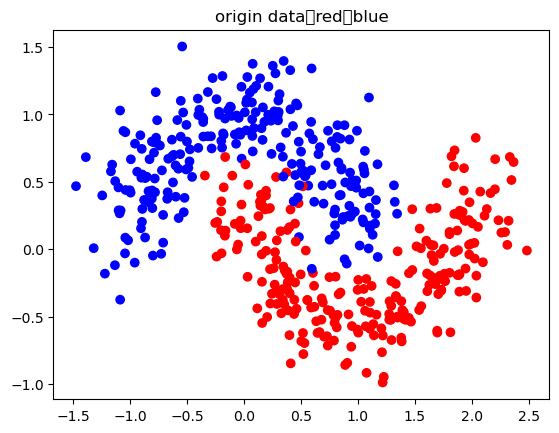

Epoch 0, Loss: 0.6969, Acc: 0.500
Epoch 200, Loss: 0.0416, Acc: 0.984
Epoch 400, Loss: 0.0332, Acc: 0.984
Epoch 600, Loss: 0.0294, Acc: 0.986
Epoch 800, Loss: 0.0258, Acc: 0.988
Epoch 1000, Loss: 0.0246, Acc: 0.988
Epoch 1200, Loss: 0.0239, Acc: 0.988
Epoch 1400, Loss: 0.0232, Acc: 0.990
Epoch 1600, Loss: 0.0230, Acc: 0.990
Epoch 1800, Loss: 0.0227, Acc: 0.988


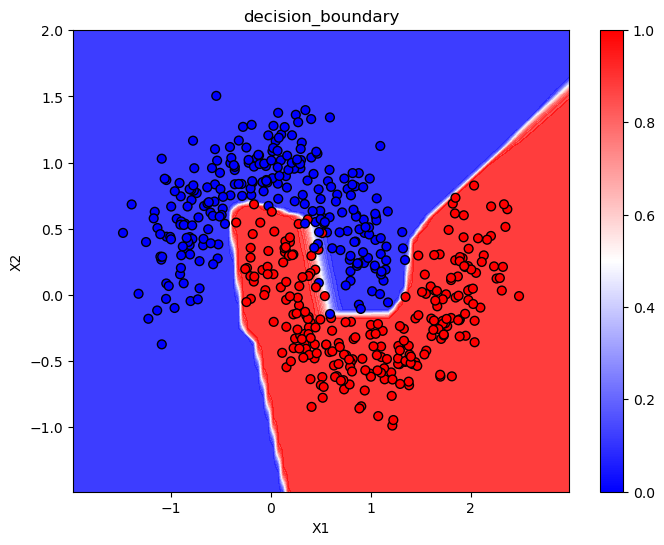

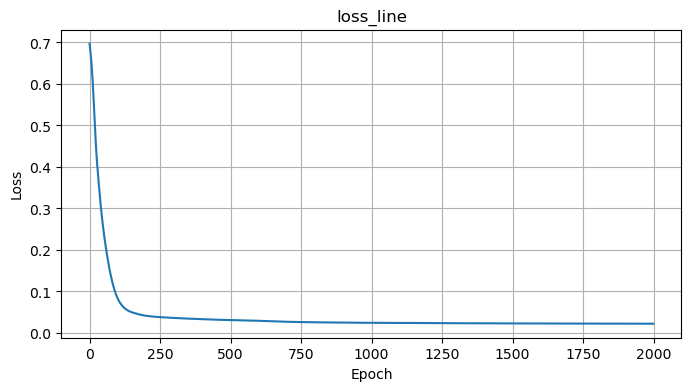

In [10]:
# 生成二分类数据
from sklearn.datasets import make_moons
import numpy as np

# 生成月亮形状的数据（二分类）
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
# 可视化
plt.scatter(X[:,0].numpy(), X[:,1].numpy(), c=y.numpy(), cmap='bwr')
plt.title('origin data：red，blue')
plt.show()

class BinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2,10)
        self.hidden = nn.Linear(10,10)
        self.fc2 = nn.Linear(10,1)
    def forward(self,x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.hidden(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = BinaryClassifier()
loss_func = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
losses = []

for epoch in range(2000):
    y_pred = model(X)
    loss = loss_func(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 200 == 0:
        acc = ((y_pred > 0.5).float() == y).float().mean()
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Acc: {acc.item():.3f}")
    
# TODO: 定义一个分类网络
# - 输入2维 (x1, x2坐标)
# - 隐藏层1: 10神经元 + ReLU
# - 隐藏层2: 10神经元 + ReLU  
# - 输出1维 + Sigmoid (因为二分类)
# TODO: 训练这个分类器
# 提示：损失函数要用 BCELoss (二分类交叉熵)
# criterion = nn.BCELoss()
# 记得最后一层要加 Sigmoid！
def plot_boundary(model, X, y):
    # 创建网格
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # 转换为张量
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    
    # 预测
    with torch.no_grad():
        pred = model(grid)
        pred = pred.numpy().reshape(xx.shape)
    
    # 画图
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, pred, alpha=0.8, cmap='bwr', levels=20)
    plt.scatter(X[:,0].numpy(), X[:,1].numpy(), c=y.numpy(), 
                cmap='bwr', edgecolors='black', s=40)
    plt.title('decision_boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.colorbar()
    plt.show()

# 调用
plot_boundary(model, X, y)

# 损失曲线
plt.figure(figsize=(8,4))
plt.plot(losses)
plt.title('loss_line')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()